# Loading Glider data and convert to OG1 format

This notebook is dedicated to **load oceanographic glider datasets** from the University of Washington Seaglider program. The data corresponds to missions conducted near the Faroe Islands and are publicly available from NOAA’s National Centers for Environmental Information (NCEI).

---

## Glider Missions

- **Overview:** [Seaglider Faroes Missions](https://iop.apl.washington.edu/seaglider/index.php?mission=Faroes)  
- **Data Server:** [NOAA NCEI Seaglider Archive](https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/)

The missions span from 2006 to 2009 and include multiple gliders (e.g., 005, 016, 101) and mission deployments. Below is a detailed breakdown of available missions and folder identifiers:

### November 2006
- 016 early recovered (124 dives) — `016/20061112` bad bad resolution data
- 101 full mission (578 dives) — `101/20061112` bad resolution of data
- 102 full mission (630 dives) — `102/20061112`

### February 2007
- 103 full mission (679 dives) — `103/20070218`
- 105 FSC section (125 dives) — _no folder_
- 104 early recovery (70 dives) — _no folder_

### June 2007
- 101 full mission (453 dives) — `101/20070609`
- 102 early recovery (22 dives) — _no folder_

### September 2007
- 012 partial mission (188 dives) — `012/20070831`
- 104 full mission (371 dives) — `104/20070901`
- 105 full mission (373 dives) — _no folder_

### November 2007
- 016 (452 dives) — `016/20071113`
- 102 (454 dives) — `102/20071113`
- 103 (524 dives) — `103/20071113`

### February 2008
- 014 (70 dives) — `014/20080214`   not at IFR
- 104 (112 dives) — `104/20080214`

### June 2008
- 102 (5 dives) — _no folder_
- 005 (386 dives) — `005/20080606`
- 016 (421 dives) — `016/20080607`

### August 2008
- 105 (13 dives) — _no folder_
- 103 (10 dives) — _no folder_
- 014 (439 dives) — `014/20080222` (_folder name misleading_)

### November 2008
- 104 (1 dive) — _no folder_  
- 101 (338 dives) — `101/20081108`
- 005 (486 dives) — `005/20081106`

### February 2009
- 103 (481 dives) — `103/20090223`
- 104 (4 dives) — _no folder_

### June 2009
- 016 (297 dives) — `016/20090605`
- 105 (346 dives) — _no folder_
- 005 (464 dives) — `005/20090829`

---
All missions that cannot be used for the analysis (bad data or not in the region) are not considered in the glider_server.yaml

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from dissipationIFR import interactive, tools, plots
import pathlib
import importlib
from seagliderOG1 import convertOG1, writers, readers

In [3]:
script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
glider_yml = parent_dir.joinpath("dissipationIFR/config/glider_data.yml")

In [4]:
glider_yml

PosixPath('/Users/u302042/Desktop/DissipationIFR/dissipationIFR/dissipationIFR/config/glider_data.yml')

In [5]:
importlib.reload(interactive)
selected_glider = interactive.interactive_glider_selection(glider_yml)

Dropdown(description='Select Glider:', index=1, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('09/07 (dives: 188)',), value='09/07 (dives: 188)')

Button(description='Confirm Selection', style=ButtonStyle())

In [7]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = readers.load_basestation_files(selected_glider['path'],start_profile=1, end_profile=selected_glider['dives'])

Loading datasets: 100%|██████████| 187/187 [00:01<00:00, 95.81file/s] 


In [8]:
### convert the dataset to OG1 format only with the variables needed
ds, var_list = convertOG1.convert_to_OG1(datasets)

Processing datasets:   0%|          | 0/187 [00:00<?, ?dataset/s]
No conversion information found for micromoles/kg to micromoles/kg

No conversion information found for cm s-1 to cm s-1

No conversion information found for micromoles/kg to micromoles/kg
Variables removed from dataset: ['eng_depth', 'eng_elaps_t', 'eng_elaps_t_0000', 'latitude_gsm', 'longitude_gsm', 'glide_angle_gsm', 'horz_speed_gsm', 'north_displacement_gsm', 'east_displacement_gsm', 'speed_gsm', 'vert_speed_gsm', 'dive_num_cast', 'density']
Processing datasets:   1%|          | 1/187 [00:00<00:44,  4.14dataset/s]

Adding variables with dimension 'sg_data_point' and time variable 'ctd_time'.
The following dimensions were not merged into the new dataset: {'gc_event', 'gps_info'}
If instrument data is missing make sure it's dimension follows the naming convention of '<instrument>_data_point'
from the ds.attrs['instrument'] list.


Processing datasets:  95%|█████████▌| 178/187 [00:25<00:01,  7.18dataset/s]/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/seagliderOG1/utilities.py:40: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  longitude=("sg_data_point", [float("nan")] * ds1.dims["sg_data_point"])
p0120179_20071002: No coord longitude - adding as NaNs to length of sg_data_point
/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/seagliderOG1/utilities.py:47: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  latitude=("sg_data_point", [float("nan")] * ds1.dims["sg_data_poi

Adding technical specifications for 'Wetlabs BB2FL-VMT' (sensor key: 'wlbb2f') from OG1_sensor_attrs.yaml
Adding technical specifications for 'SeaBird SBE 41 CTD' (sensor key: 'sbe41') from OG1_sensor_attrs.yaml
Adding technical specifications for 'Seabird SBE43F' (sensor key: 'sbe43') from OG1_sensor_attrs.yaml
The following HDM parameters were found: ['VBD_MIN_CNTS', 'VBD_CNTS_PER_CC', 'VBD_CC_PER_CNTS', 'MASS', 'VOLMAX', 'C_VBD', 'HD_A', 'HD_B', 'HD_C']


In [9]:
from dissipationIFR.config import variables

In [10]:
w_meas = tools.calc_vertical_velocity(ds.TIME.values, ds.DEPTH.values)
ds['W_MEAS'] = (('N_MEASUREMENTS'), w_meas)
ds['W_MEAS'].attrs = variables.variables['W_MEAS']['attributes']

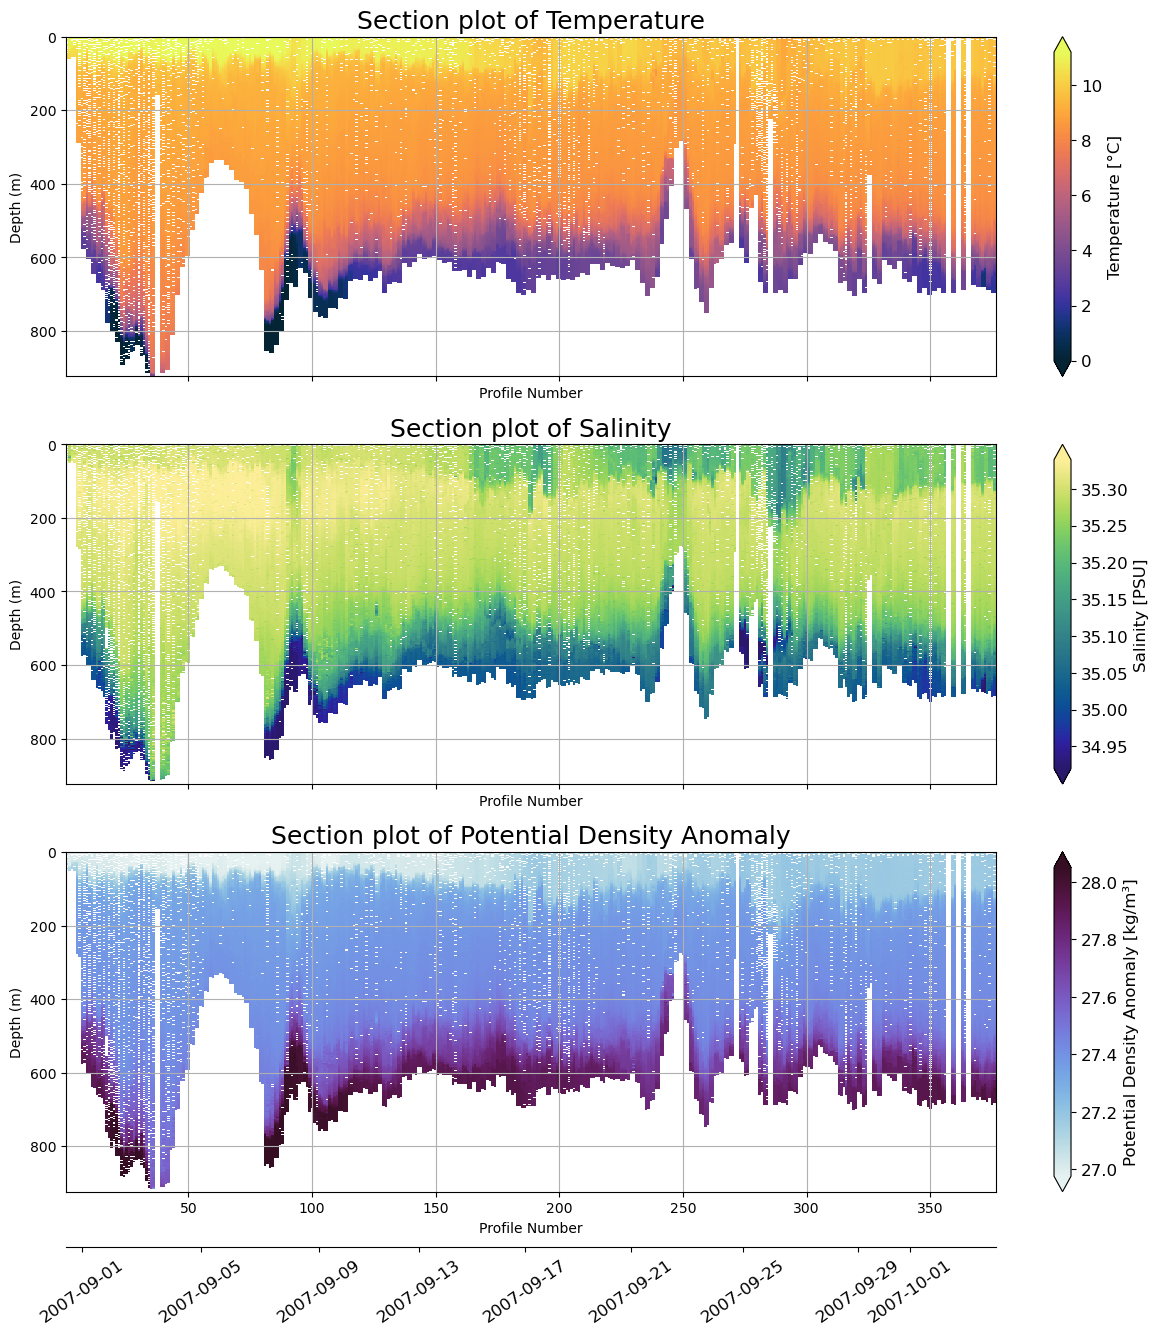

In [12]:
fig, ax = plt.subplots(3,1, figsize=(15, 15),sharex=True)
with plt.style.context(plots.plotting_style):
    ax[0], cbar0, _ = plots.plot_section(ds, "TEMP", method="pcolormesh", log_scale=False, show_time_axis=False, ax=ax[0])
    ax[1], cbar1, _ = plots.plot_section(ds, "PSAL", method="pcolormesh", log_scale=False, show_time_axis=False, ax=ax[1])
    ax[2], cbar2, _ = plots.plot_section(ds, "SIGMA_T", method="pcolormesh", log_scale=False, show_time_axis=True, ax=ax[2])
    plt.show()

In [14]:
### cut the dataset to the time period of interest
mask = (ds['TIME'] > np.datetime64('2006-01-01')) & (ds['TIME'] < np.datetime64('2009-12-31'))
ds = ds.where(mask, drop=True)

In [15]:
ds.attrs['Glider'] = selected_glider['glider']
ds.attrs['Mission'] = selected_glider['mission']

In [16]:
file_name = "all_data_OG1.nc"
dataset_path = pathlib.Path(selected_glider['path']) / file_name
remove_old = False

# Check first if the dataset already exists to avoid overwriting
if not dataset_path.exists():
    writers.save_dataset(ds, dataset_path)
else:
    if remove_old:
        dataset_path.unlink()  # remove the old file
        writers.save_dataset(ds, dataset_path)
    else:
        print("Dataset already exists at the specified location. No overwriting.")

Dataset already exists at the specified location. No overwriting.
